# Fusão temporal — GPS, posição local e EKF2 (`ekf2_innovations`)

**Continuação de:** `Infos_local_position.ipynb` e `Infos_gps_position.ipynb`.

**Objetivos deste notebook:**

1. Alinhar **`vehicle_local_position`** com **`vehicle_gps_position`** no mesmo `timestamp` (`merge_asof`).
2. Incorporar **`ekf2_innovations`** (export PX4; substitui o nome antigo `estimator_innovations` em muitos logs).
3. Visualizar **incertezas duplicadas** (`eph`/`epv` no GPS vs no local) e uma **norma simples** das inovações de velocidade/posição do EKF.
4. Deixar explícito o **próximo passo** de modelagem (LSTM + partição por voo).


## Notas metodológicas

- **`merge_asof`** assume séries ordenadas por `timestamp` (μs). O passo mais denso (tipicamente **local position**) fica à **esquerda**; GPS e inovações, com menos amostras, são alinhadas **para trás** (`direction='backward'`).
- Colunas repetidas: só `timestamp`, `eph`, `epv` aparecem nos dois primeiros CSV — usamos sufixos `_loc` e `_gps`.
- **Altitude:** GPS `alt` está em **mm** AMSL; `z` local é **NED** (positivo para baixo). Aqui **não** forçamos igualdade física direta; comparamos tendências só após conversões e com **ressalva** no texto.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")


def find_px4_quad_sitl() -> Path:
    'Sobe a partir do cwd até achar PX4-QUAD-SITL.'
    here = Path.cwd().resolve()
    for anchor in [here, *here.parents]:
        p = anchor / "data" / "UAVAttackData" / "Simulated - OTU Survey" / "PX4-QUAD-SITL"
        if p.is_dir():
            return p
    raise FileNotFoundError("Não encontrei data/UAVAttackData/.../PX4-QUAD-SITL.")


BASE_PATH = find_px4_quad_sitl()
NORMAL = BASE_PATH / "Normal"
SPOOFING = BASE_PATH / "GPS Spoofing"
DOS = BASE_PATH / "Ping DoS"

print("BASE_PATH:", BASE_PATH)


def pick_vehicle_local_position_csv(folder: Path) -> Path:
    matches = sorted(folder.glob("*vehicle_local_position*.csv"))
    matches = [m for m in matches if "setpoint" not in m.name and "groundtruth" not in m.name]
    if not matches:
        raise FileNotFoundError(folder)
    return matches[0]


def log_prefix(folder: Path) -> str:
    name = pick_vehicle_local_position_csv(folder).name
    suf = "_vehicle_local_position_0.csv"
    if not name.endswith(suf):
        raise ValueError(f"Nome inesperado: {name}")
    return name[: -len(suf)]


BASE_PATH: /Users/caiolima/Documents/TCC/data/UAVAttackData/Simulated - OTU Survey/PX4-QUAD-SITL


## 1. Carregar trio (local, GPS, EKF2) e `merge_asof`

Um voo por pasta; prefixo inferido do ficheiro `vehicle_local_position`.


In [2]:
def load_merged_for_folder(folder: Path, condition: str) -> pd.DataFrame:
    pref = log_prefix(folder)
    path_loc = folder / f"{pref}_vehicle_local_position_0.csv"
    path_gps = folder / f"{pref}_vehicle_gps_position_0.csv"
    path_ekf = folder / f"{pref}_ekf2_innovations_0.csv"

    loc = pd.read_csv(path_loc, sep=",").sort_values("timestamp")
    gps = pd.read_csv(path_gps, sep=",").sort_values("timestamp")
    if not path_ekf.is_file():
        raise FileNotFoundError(path_ekf)
    ekf = pd.read_csv(path_ekf, sep=",").sort_values("timestamp")

    m = pd.merge_asof(
        loc,
        gps,
        on="timestamp",
        suffixes=("_loc", "_gps"),
        direction="backward",
    )
    m = pd.merge_asof(
        m.sort_values("timestamp"),
        ekf.sort_values("timestamp"),
        on="timestamp",
        direction="backward",
    )
    m = m.assign(condition=condition)
    return m


merged = pd.concat(
    [
        load_merged_for_folder(NORMAL, "Normal"),
        load_merged_for_folder(SPOOFING, "GPS Spoofing"),
        load_merged_for_folder(DOS, "Ping DoS"),
    ],
    ignore_index=True,
)

print("linhas merged:", len(merged), "| colunas:", merged.shape[1])
display(merged.groupby("condition").size().rename("n").to_frame())
merged[["timestamp", "condition", "x", "y", "lat", "vel_pos_innov[0]"]].head(2)


linhas merged: 44957 | colunas: 107


/var/folders/8_/_x4q463d1yl_x911vq7_v8kr0000gn/T/ipykernel_84322/1315067413.py:26: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  m = m.assign(condition=condition)


,n
condition,
GPS Spoofing,15453
Normal,14765
Ping DoS,14739


,timestamp,condition,x,y,lat,vel_pos_innov[0]
0,14148000,Normal,0.005196,0.000961,439451638,-0.015331
1,14244000,Normal,0.006151,0.000024,439451638,-0.015331


## 2. Derivadas para gráficos

- `t_rel_s`: tempo desde o início **daquele** voo (min `timestamp` por `condition`).
- `alt_m_gps`: `alt` GPS em metros (÷1000 a partir de mm).
- `innov_vel_norm`: norma L2 de `vel_pos_innov[0]`, `[1]`, `[2]` (se existirem).


In [3]:
def add_time_and_innov_norm(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["t_rel_s"] = out.groupby("condition")["timestamp"].transform(
        lambda s: (s.astype("int64") - s.astype("int64").min()) / 1e6
    )
    if "alt" in out.columns:
        out["alt_m_gps"] = out["alt"] / 1000.0
    cols = [c for c in ["vel_pos_innov[0]", "vel_pos_innov[1]", "vel_pos_innov[2]"] if c in out.columns]
    if cols:
        M = out[cols].astype(float).to_numpy()
        out["innov_vel_norm"] = np.sqrt(np.sum(M * M, axis=1))
    else:
        out["innov_vel_norm"] = np.nan
    out["v_xy_gps"] = np.sqrt(out["vel_n_m_s"].astype(float) ** 2 + out["vel_e_m_s"].astype(float) ** 2)
    out["v_xy_loc"] = np.sqrt(out["vx"].astype(float) ** 2 + out["vy"].astype(float) ** 2)
    out["dv_xy_m_s"] = np.abs(out["v_xy_loc"] - out["v_xy_gps"])
    return out


m = add_time_and_innov_norm(merged)
for cond in m["condition"].unique():
    sub = m.loc[m["condition"] == cond]
    print(cond, "innov_vel_norm median", float(sub["innov_vel_norm"].median()), "| dv_xy median", float(sub["dv_xy_m_s"].median()))


Normal innov_vel_norm median 0.06714022903391602 | dv_xy median 0.037893551156942706
GPS Spoofing innov_vel_norm median 0.06894574680059827 | dv_xy median 0.03611656077511771
Ping DoS innov_vel_norm median 0.06762141169574443 | dv_xy median 0.037817602679453444


## 3. Incertezas `eph` / `epv` — local vs GPS (mesmo instante alinhado)

Três filas (Normal / Spoofing / Ping DoS): séries `eph_loc` vs `eph_gps` (eixo direito pode repetir escala).


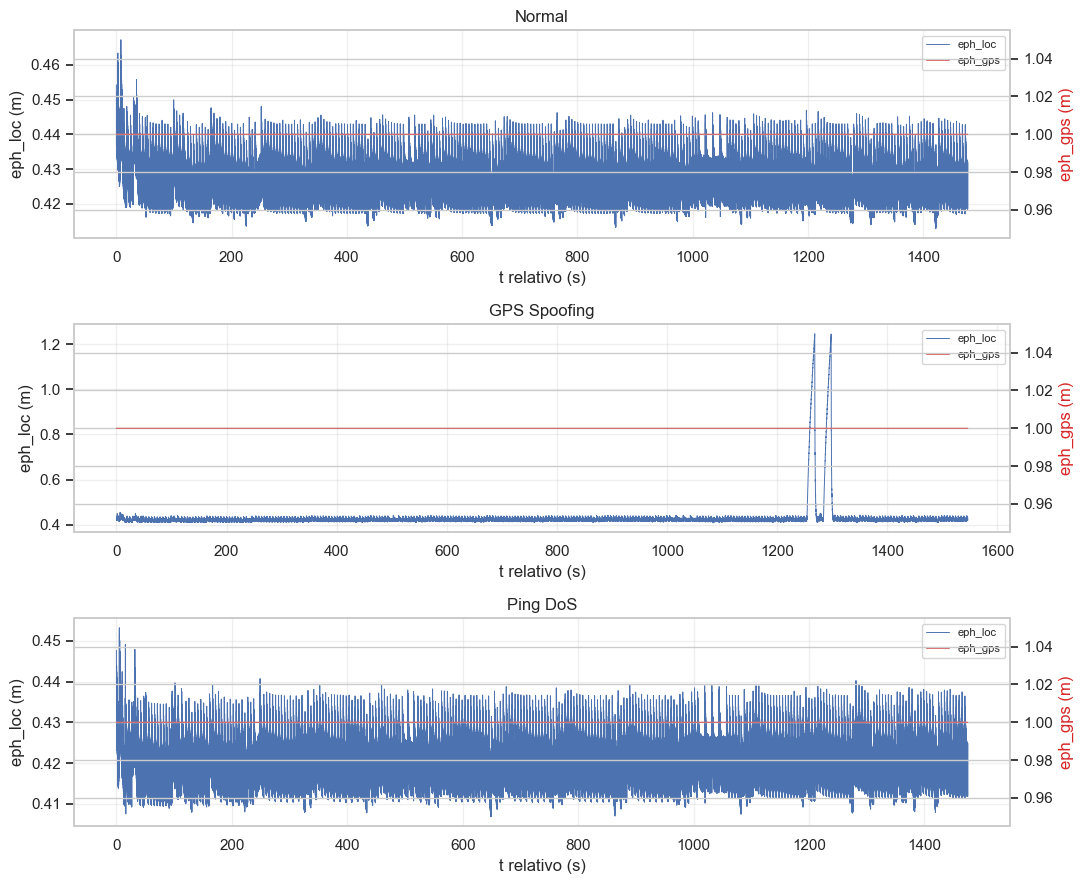

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=False)
for ax, cond in zip(axes, ["Normal", "GPS Spoofing", "Ping DoS"]):
    d = m[m["condition"] == cond]
    ax.plot(d["t_rel_s"], d["eph_loc"], lw=0.7, label="eph_loc")
    ax2 = ax.twinx()
    ax2.plot(d["t_rel_s"], d["eph_gps"], lw=0.7, color="tab:red", alpha=0.75, label="eph_gps")
    ax.set_ylabel("eph_loc (m)")
    ax2.set_ylabel("eph_gps (m)", color="tab:red")
    ax.set_title(cond)
    ax.set_xlabel("t relativo (s)")
    ax.grid(True, alpha=0.3)
    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()


## 4. Norma das inovações EKF (`vel_pos_innov[0:2]`)

Valor alto sugere **stress** do filtro face ao modelo de medida; interpretar junto com o cenário (spoofing vs DoS).


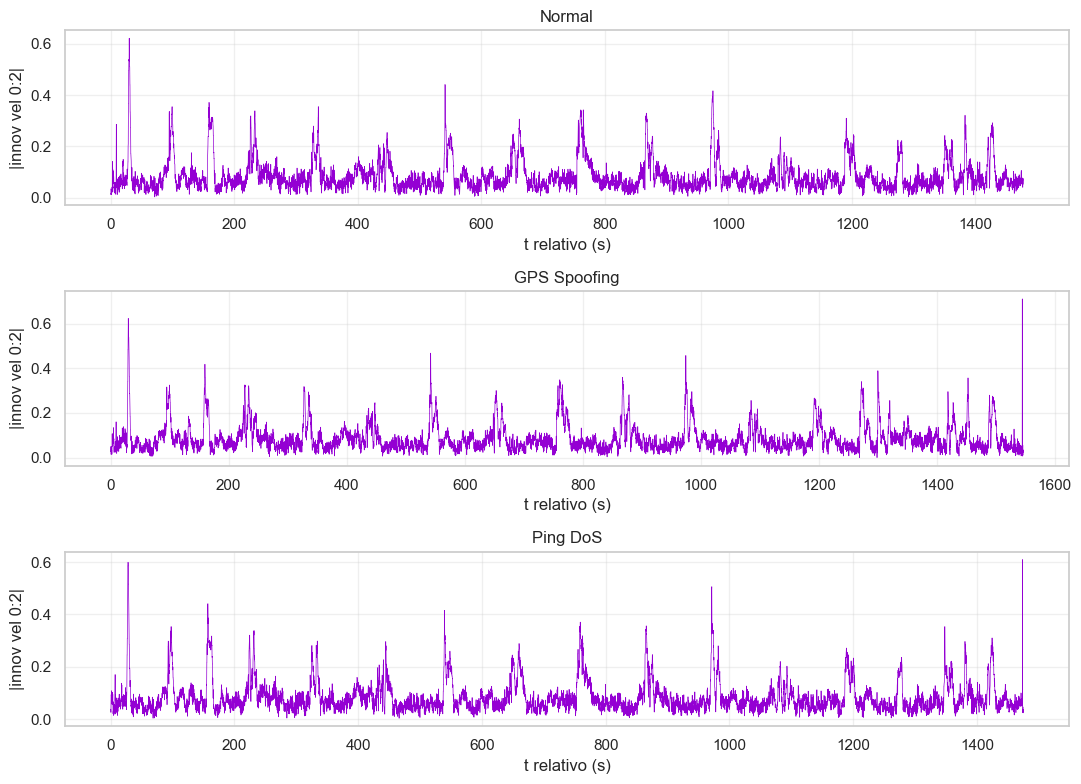

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=False)
for ax, cond in zip(axes, ["Normal", "GPS Spoofing", "Ping DoS"]):
    d = m[m["condition"] == cond]
    ax.plot(d["t_rel_s"], d["innov_vel_norm"], lw=0.5, color="darkviolet")
    ax.set_title(cond)
    ax.set_ylabel("|innov vel 0:2|")
    ax.set_xlabel("t relativo (s)")
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 5. Coerência de velocidade horizontal — local vs GPS

`|v_xy_loc − v_xy_gps|` após alinhamento temporal (não é erro de ground truth; é **discrepância** entre duas estimativas).


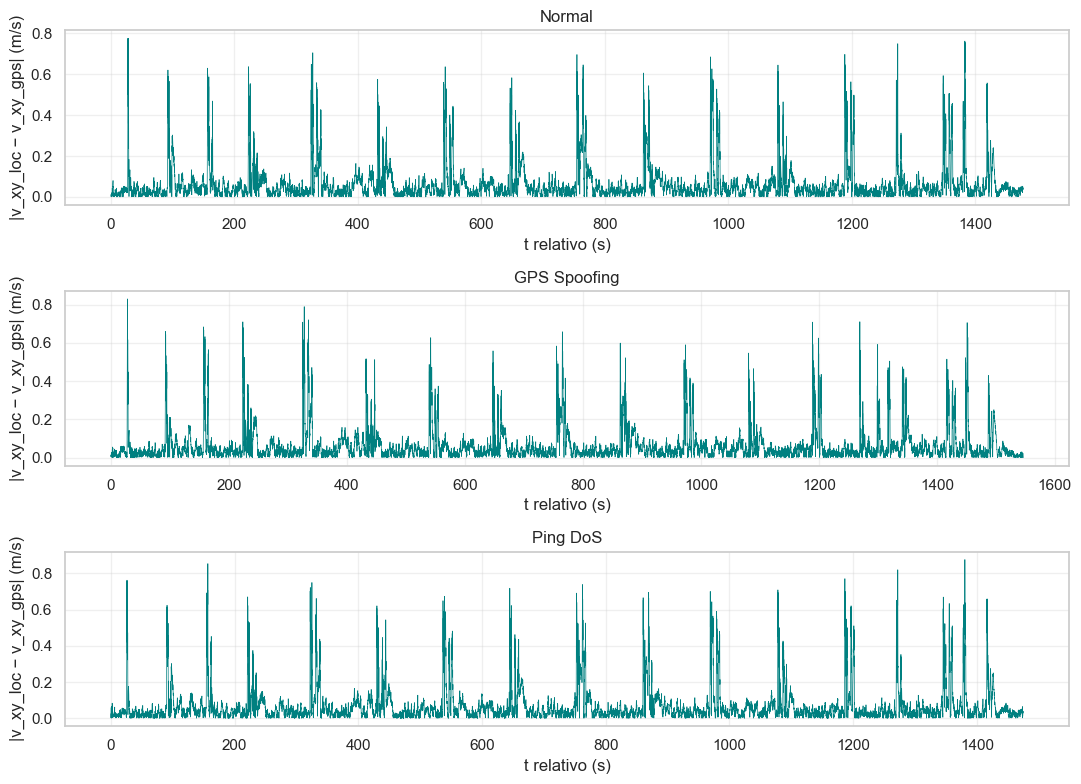

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=False)
for ax, cond in zip(axes, ["Normal", "GPS Spoofing", "Ping DoS"]):
    d = m[m["condition"] == cond]
    ax.plot(d["t_rel_s"], d["dv_xy_m_s"], lw=0.5, color="teal")
    ax.set_title(cond)
    ax.set_ylabel("|v_xy_loc − v_xy_gps| (m/s)")
    ax.set_xlabel("t relativo (s)")
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 6. Boxplot — discrepância de velocidade e norma de inovação

Comparação **agregada** por condição (três voos diferentes).


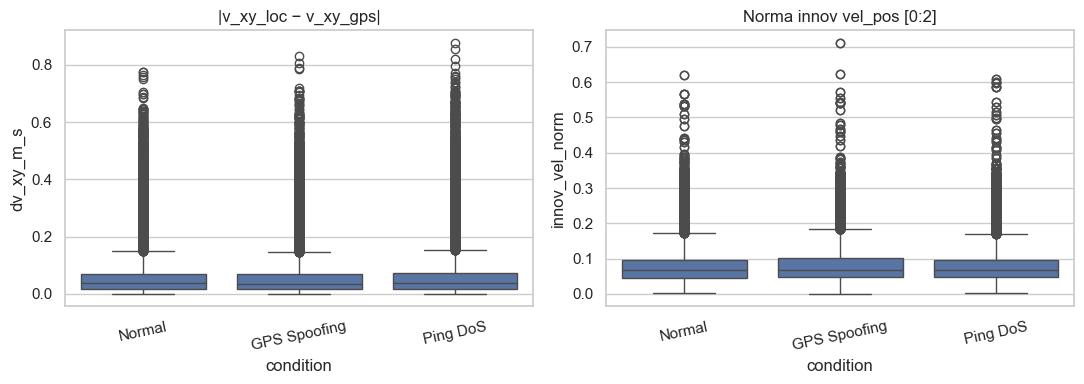

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.boxplot(data=m, x="condition", y="dv_xy_m_s", ax=axes[0])
axes[0].set_title("|v_xy_loc − v_xy_gps|")
axes[0].tick_params(axis="x", rotation=12)
sns.boxplot(data=m, x="condition", y="innov_vel_norm", ax=axes[1])
axes[1].set_title("Norma innov vel_pos [0:2]")
axes[1].tick_params(axis="x", rotation=12)
plt.tight_layout()
plt.show()


## 7. Próximos passos (modelagem)

1. **Features por janela** (ex.: 20–50 passos): estatísticas de `innov_vel_norm`, `dv_xy_m_s`, `eph_loc`, `r_xy` (calcular a partir de `x,y` no mesmo `m`), etc.
2. **Partição:** treino/teste **por ficheiro de voo** (ou por pasta), nunca linhas aleatórias dentro do mesmo log.
3. **LSTM / baseline** com as mesmas boas práticas do ramo rede (`Dataset_T-ITS`).
4. **Texto do TCC:** ligar este ramo **físico/fusão** ao ramo **ciber** como IDS complementar ou multimodal (sem afirmar fusão temporal com o CSV T-ITS sem evidência de coleta conjunta).
